In [1]:
import os
from pathlib import Path

import yaml
import pandas as pd

log_root = Path("logs/thinker")

# 분석할 폴더 이름을 여기 리스트에 넣으세요.
# 비워두면(log_root 아래 모든 폴더를 사용)
target_run_names = [
    "thinker-20251223-140527",
]

run_dirs = sorted([p for p in log_root.iterdir() if p.is_dir()])

if target_run_names:
    run_dirs = [p for p in run_dirs if p.name in target_run_names]

run_configs = {}
run_logs = {}
run_logs_model = {}

for run_dir in run_dirs:
    run_name = run_dir.name
    cfg_path = run_dir / "config_c.yaml"
    log_csv = run_dir / "logs.csv"
    log_model_csv = run_dir / "logs_model.csv"

    if not cfg_path.exists():
        print(f"[skip] {run_name}: no config_c.yaml")
        continue

    # config_c.yaml
    try:
        with cfg_path.open("r") as f:
            cfg = yaml.safe_load(f)
    except Exception as e:
        print(f"[error] {run_name}: failed to read config ({e})")
        continue
    run_configs[run_name] = cfg

    # logs.csv
    if log_csv.exists():
        try:
            run_logs[run_name] = pd.read_csv(log_csv)
        except Exception as e:
            print(f"[warn] {run_name}: failed to read logs.csv ({e})")
    else:
        print(f"[warn] {run_name}: no logs.csv")

    # logs_model.csv
    if log_model_csv.exists():
        try:
            run_logs_model[run_name] = pd.read_csv(log_model_csv)
        except Exception as e:
            print(f"[warn] {run_name}: failed to read logs_model.csv ({e})")
    else:
        print(f"[warn] {run_name}: no logs_model.csv")

print(f"Loaded {len(run_configs)} configs, {len(run_logs)} actor logs, {len(run_logs_model)} model logs.")
print("Runs loaded:", list(run_configs.keys()))


Loaded 1 configs, 1 actor logs, 1 model logs.
Runs loaded: ['thinker-20251223-140527']


# NOOP frequency

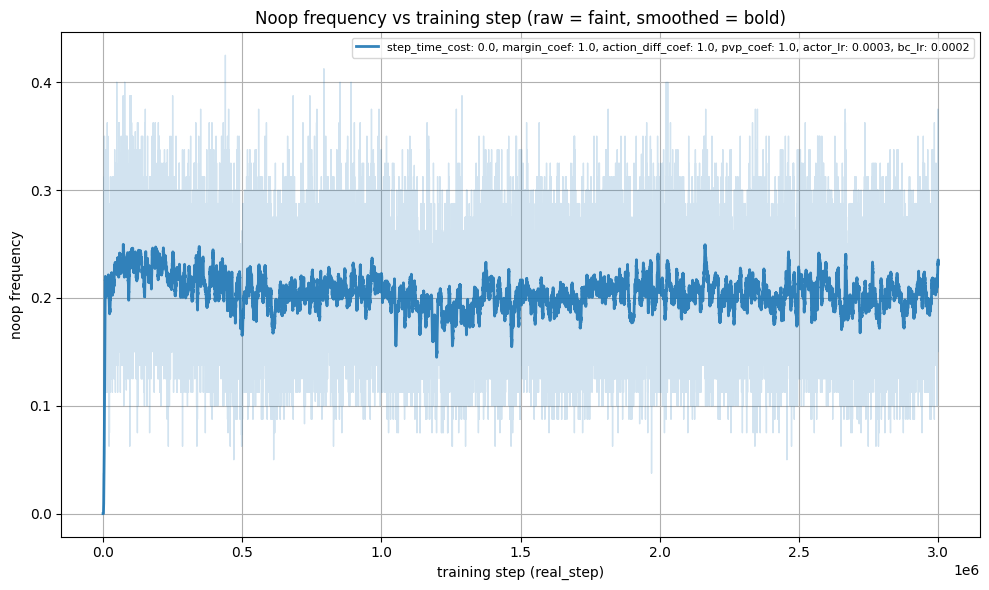

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not run_logs:
    raise RuntimeError("run_logs is empty. Run the previous cell first.")

# ==== 설정 ====
max_step = 3000_000        # 예: 3_000_000 처럼 최대 step 지정, 전체 사용하려면 None
smoothing_window = 50    # 이동평균 윈도우 길이 (step 개수 기준)
# ===============

plt.figure(figsize=(10, 6))

for idx, (run_name, df) in enumerate(run_logs.items()):
    cfg = run_configs.get(run_name, {})

    step_time_cost   = cfg.get("step_time_cost", None)
    margin_coef      = cfg.get("icopro_margin_coef", None)
    action_diff_coef = cfg.get("icopro_action_diff_coef", None)
    pvp_coef         = cfg.get("icopro_pvp_coef", None)
    actor_lr         = cfg.get("actor_learning_rate", None)
    bc_lr            = cfg.get("icopro_actor_lr", None)  # bc learning rate

    if "real_step" not in df.columns or "noop_frequency" not in df.columns:
        print(f"[skip] {run_name}: missing 'real_step' or 'noop_frequency' columns")
        continue

    x = df["real_step"].to_numpy()
    y = df["noop_frequency"].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    if max_step is not None:
        mask &= (x <= max_step)
    x, y = x[mask], y[mask]

    if x.size == 0:
        print(f"[skip] {run_name}: empty after filtering")
        continue

    # smoothing (moving average)
    y_smooth = pd.Series(y).rolling(
        window=max(1, smoothing_window),
        min_periods=1
    ).mean().to_numpy()

    color = plt.cm.tab10(idx % 10)

    # 원래 값: 희미하게 표시
    plt.plot(x, y, color=color, alpha=0.2, linewidth=1)

    # smoothed 값: 진하게, legend용
    label = (
        f"step_time_cost: {step_time_cost}, "
        f"margin_coef: {margin_coef}, "
        f"action_diff_coef: {action_diff_coef}, "
        f"pvp_coef: {pvp_coef}, "
        f"actor_lr: {actor_lr}, "
        f"bc_lr: {bc_lr}"
    )
    plt.plot(x, y_smooth, color=color, alpha=0.9, linewidth=2, label=label)

plt.xlabel("training step (real_step)")
plt.ylabel("noop frequency")
plt.title("Noop frequency vs training step (raw = faint, smoothed = bold)")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


# rmean_episode_return

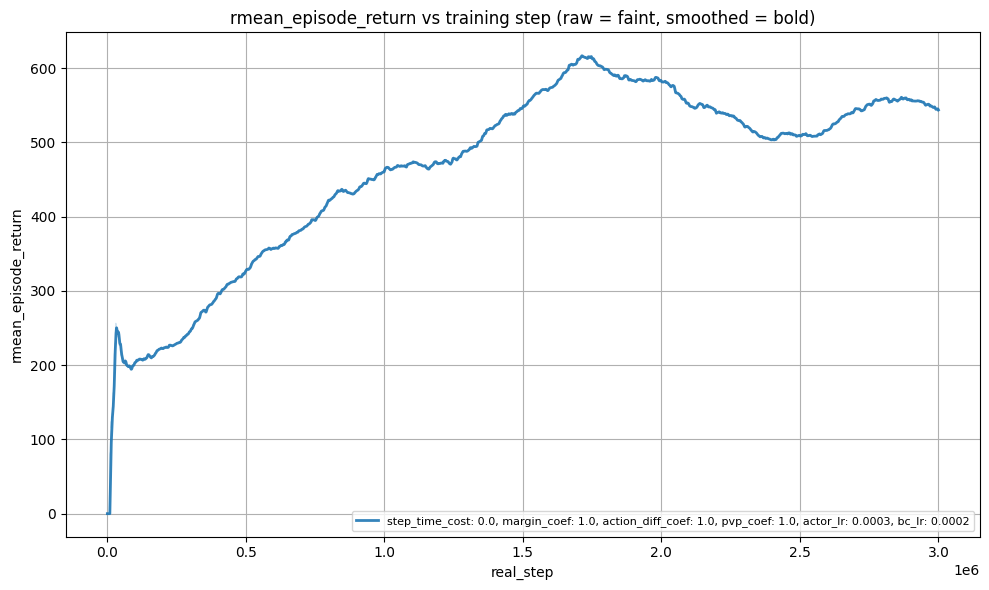

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not run_logs:
    raise RuntimeError("run_logs is empty. Run the previous cell first.")

# ==== 설정 ====
max_step = 3000_000       # 전체 사용하려면 None
smoothing_window = 50   # 이동평균 윈도우 길이
# ===============

plt.figure(figsize=(10, 6))

for idx, (run_name, df) in enumerate(run_logs.items()):
    cfg = run_configs.get(run_name, {})

    step_time_cost   = cfg.get("step_time_cost", None)
    margin_coef      = cfg.get("icopro_margin_coef", None)
    action_diff_coef = cfg.get("icopro_action_diff_coef", None)
    pvp_coef         = cfg.get("icopro_pvp_coef", None)
    actor_lr         = cfg.get("actor_learning_rate", None)
    bc_lr            = cfg.get("icopro_actor_lr", None)

    # x축: real_step 우선, 없으면 step
    x_col = "real_step" if "real_step" in df.columns else "step"

    if x_col not in df.columns or "rmean_episode_return" not in df.columns:
        print(f"[skip] {run_name}: missing '{x_col}' or 'rmean_episode_return' columns")
        continue

    x = df[x_col].to_numpy()
    y = df["rmean_episode_return"].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    if max_step is not None:
        mask &= (x <= max_step)
    x, y = x[mask], y[mask]

    if x.size == 0:
        print(f"[skip] {run_name}: empty after filtering")
        continue

    # smoothing (moving average)
    y_smooth = pd.Series(y).rolling(
        window=max(1, smoothing_window),
        min_periods=1
    ).mean().to_numpy()

    color = plt.cm.tab10(idx % 10)

    # 원래 값: 희미하게 표시
    plt.plot(x, y, color=color, alpha=0.2, linewidth=1)

    # smoothed 값: 진하게, legend용
    label = (
        f"step_time_cost: {step_time_cost}, "
        f"margin_coef: {margin_coef}, "
        f"action_diff_coef: {action_diff_coef}, "
        f"pvp_coef: {pvp_coef}, "
        f"actor_lr: {actor_lr}, "
        f"bc_lr: {bc_lr}"
    )
    plt.plot(x, y_smooth, color=color, alpha=0.9, linewidth=2, label=label)

plt.xlabel(x_col)
plt.ylabel("rmean_episode_return")
plt.title("rmean_episode_return vs training step (raw = faint, smoothed = bold)")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


# Human action prediction accuracy

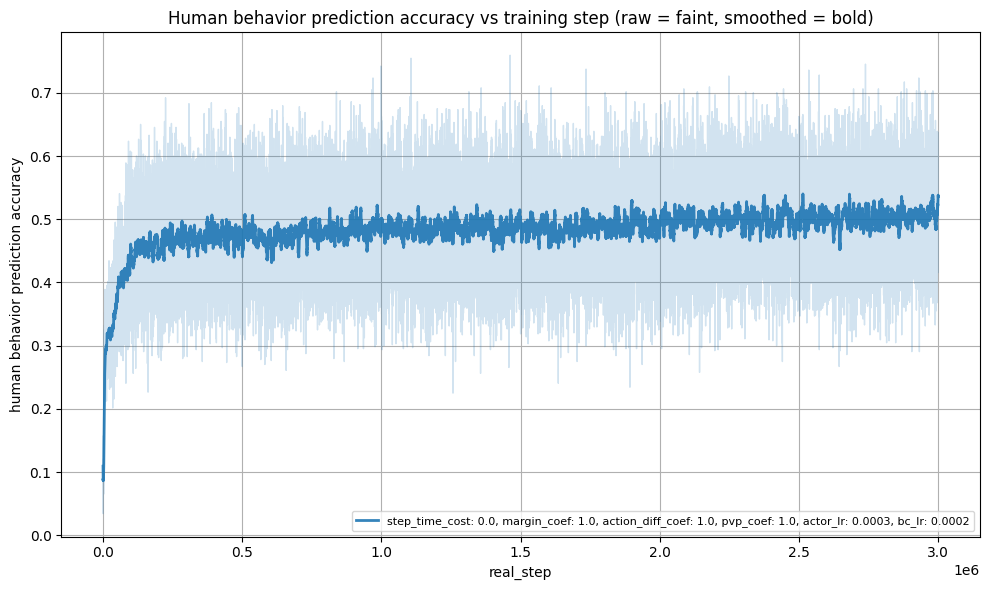

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not run_logs:
    raise RuntimeError("run_logs is empty. Run the previous cell first.")

# ==== 설정 ====
max_step = 3000_000       # 전체 사용하려면 None
smoothing_window = 50   # 이동평균 윈도우 길이
# ===============

plt.figure(figsize=(10, 6))

for idx, (run_name, df) in enumerate(run_logs.items()):
    cfg = run_configs.get(run_name, {})

    step_time_cost   = cfg.get("step_time_cost", None)
    margin_coef      = cfg.get("icopro_margin_coef", None)
    action_diff_coef = cfg.get("icopro_action_diff_coef", None)
    pvp_coef         = cfg.get("icopro_pvp_coef", None)
    actor_lr         = cfg.get("actor_learning_rate", None)
    bc_lr            = cfg.get("icopro_actor_lr", None)

    # x축: real_step 우선, 없으면 step
    x_col = "real_step" if "real_step" in df.columns else "step"
    y_col = "icopro/actor/accuracy"  # human behavior prediction accuracy

    if x_col not in df.columns or y_col not in df.columns:
        print(f"[skip] {run_name}: missing '{x_col}' or '{y_col}' columns")
        continue

    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y)
    if max_step is not None:
        mask &= (x <= max_step)
    x, y = x[mask], y[mask]

    if x.size == 0:
        print(f"[skip] {run_name}: empty after filtering")
        continue

    # smoothing (moving average)
    y_smooth = pd.Series(y).rolling(
        window=max(1, smoothing_window),
        min_periods=1
    ).mean().to_numpy()

    color = plt.cm.tab10(idx % 10)

    # 원래 값: 희미하게 표시
    plt.plot(x, y, color=color, alpha=0.2, linewidth=1)

    # smoothed 값: 진하게, legend용
    label = (
        f"step_time_cost: {step_time_cost}, "
        f"margin_coef: {margin_coef}, "
        f"action_diff_coef: {action_diff_coef}, "
        f"pvp_coef: {pvp_coef}, "
        f"actor_lr: {actor_lr}, "
        f"bc_lr: {bc_lr}"
    )
    plt.plot(x, y_smooth, color=color, alpha=0.9, linewidth=2, label=label)

plt.xlabel(x_col)
plt.ylabel("human behavior prediction accuracy")
plt.title("Human behavior prediction accuracy vs training step (raw = faint, smoothed = bold)")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()


# overall

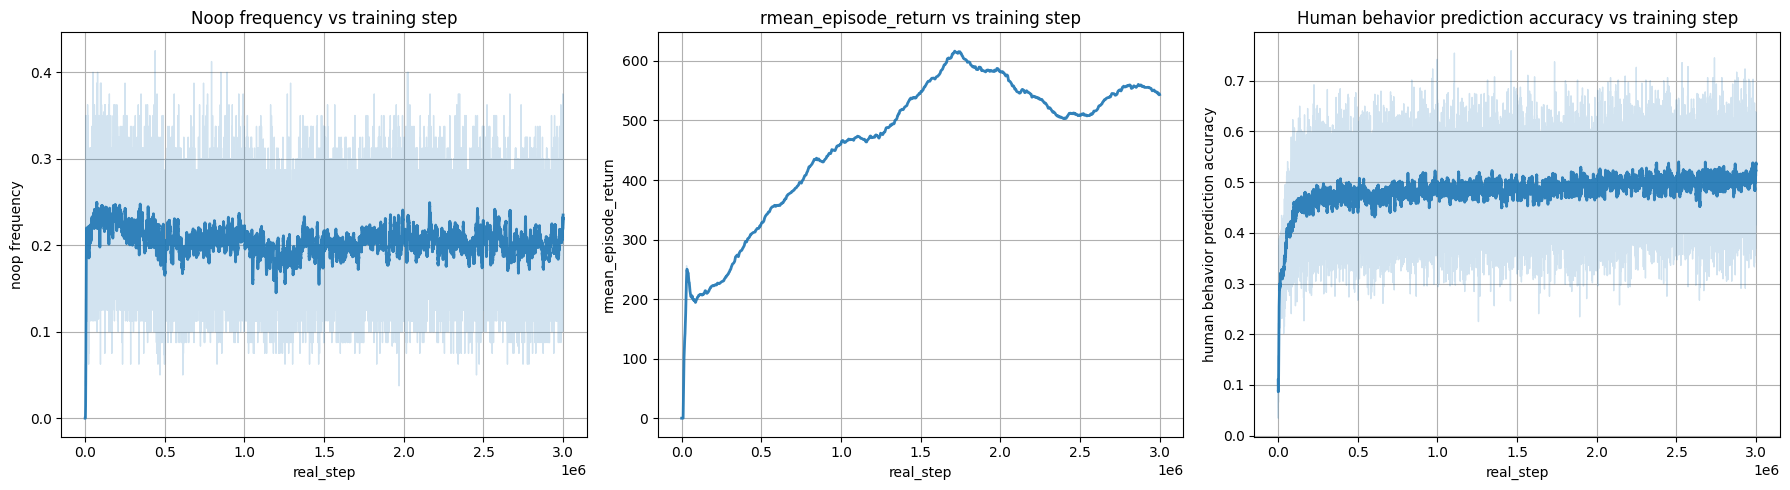

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if not run_logs:
    raise RuntimeError("run_logs is empty. Run the previous cell first.")

# ==== settings ====
max_step = 3000_000     # set to None to use full range
smoothing_window = 50   # moving average window (in steps)
# ==================

def plot_metric(ax, y_col, y_label, title):
    for idx, (run_name, df) in enumerate(run_logs.items()):
        x_col = "real_step" if "real_step" in df.columns else "step"

        if x_col not in df.columns or y_col not in df.columns:
            print(f"[skip] {run_name}: missing '{x_col}' or '{y_col}' columns")
            continue

        x = df[x_col].to_numpy()
        y = df[y_col].to_numpy()
        mask = np.isfinite(x) & np.isfinite(y)
        if max_step is not None:
            mask &= (x <= max_step)
        x, y = x[mask], y[mask]

        if x.size == 0:
            print(f"[skip] {run_name}: empty after filtering")
            continue

        y_smooth = pd.Series(y).rolling(
            window=max(1, smoothing_window),
            min_periods=1
        ).mean().to_numpy()

        color = plt.cm.tab10(idx % 10)
        ax.plot(x, y, color=color, alpha=0.2, linewidth=1)
        ax.plot(x, y_smooth, color=color, alpha=0.9, linewidth=2)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_metric(
    axes[0],
    y_col="noop_frequency",
    y_label="noop frequency",
    title="Noop frequency vs training step"
)

plot_metric(
    axes[1],
    y_col="rmean_episode_return",
    y_label="rmean_episode_return",
    title="rmean_episode_return vs training step"
)

plot_metric(
    axes[2],
    y_col="icopro/actor/accuracy",
    y_label="human behavior prediction accuracy",
    title="Human behavior prediction accuracy vs training step"
)

plt.tight_layout()
plt.show()


### action_seq 분석

In [40]:
import random
from scipy import stats
import re
import numpy as np
from pathlib import Path

# ===== user config =====
SEQ_LEN = 50
NUM_SEQS = 100

HUMAN_BASE_DIR = Path.home() / "thinker" / "behavioral_data_block"
HUMAN_SUBJECT = 1    # or None
HUMAN_SESSION = 1    # or None
HUMAN_BLOCK = 3   # or None
HUMAN_GAME_ID = 2    # or None

RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

# ===== helpers =====
_FILENAME_RE = re.compile(
    r"sub(?P<sub>\d+)-ses(?P<ses>\d+)-block(?P<block>\d+)-game(?P<game>\d+)\.npz$"
)

# Thinker baseline 행동 데이터 (여러 폴더 지정 가능)
THINKER_BASE_DIRS = [
    #Path("test/thinker-20250806-002733-4000032-0"),
    Path('test/test/spaceinvaders_2e6_0.npy'),
    Path('test/test/spaceinvaders_2e6_1.npy'),
    Path('test/test/spaceinvaders_2e6_2.npy'),
    # 필요시 다른 폴더 추가
    # Path("test/thinker-20251130-155103-195600-0"),
]

# Imitation 에이전트 행동 데이터 (여러 폴더 지정 가능)
IMIT_DIRS = [
    Path("test/sub001-ses01-block3-game2/video_stat_000.npy"),
    Path("test/sub001-ses01-block3-game2/video_stat_001.npy"),
    Path("test/sub001-ses01-block3-game2/video_stat_002.npy"),
    # 필요시 다른 폴더 추가
]

# 코사인 유사도 샘플링 개수 (각 비교당 최대 페어 수)
NUM_PAIRS = 1000

RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)
random.seed(RNG_SEED)


In [41]:
import numpy as np
from pathlib import Path


def _argmax_actions(actions: np.ndarray) -> np.ndarray:
    actions = np.asarray(actions)
    if actions.ndim == 1:
        return actions.astype(int)
    if actions.ndim == 2:
        return actions.argmax(axis=-1)
    raise ValueError(f"Unsupported action array shape {actions.shape}")

def _iter_human_npz_paths(
    base_dir: Path,
    subject: int | None = None,
    session: int | None = None,
    block: int | None = None,
    game_id: int | None = None,
):
    if subject is None:
        sub_dirs = sorted(base_dir.glob("sub-*"))
    else:
        sub_dirs = [base_dir / f"sub-{subject:03d}"]

    for sub_dir in sub_dirs:
        if not sub_dir.exists():
            continue
        if session is None:
            ses_dirs = sorted(sub_dir.glob("ses-*"))
        else:
            ses_dirs = [sub_dir / f"ses-{session:02d}"]

        for ses_dir in ses_dirs:
            if not ses_dir.exists():
                continue
            for path in sorted(ses_dir.glob("*.npz")):
                m = _FILENAME_RE.match(path.name)
                if not m:
                    continue
                if subject is not None and int(m["sub"]) != subject:
                    continue
                if session is not None and int(m["ses"]) != session:
                    continue
                if block is not None and int(m["block"]) != block:
                    continue
                if game_id is not None and int(m["game"]) != game_id:
                    continue
                yield path

def sample_human_action_sequences(
    seq_len: int,
    num_seqs: int,
    base_dir: Path,
    subject: int | None = None,
    session: int | None = None,
    block: int | None = None,
    game_id: int | None = None,
):
    """
    Load human action sequences from:
      base_dir/sub-###/ses-##/sub###-ses##-block#-game#.npz

    Any of subject/session/block/game_id can be None to include all matches.
    Returns (N, L*A) vectors and num_actions.
    """
    npz_paths = list(_iter_human_npz_paths(
        base_dir=base_dir,
        subject=subject,
        session=session,
        block=block,
        game_id=game_id,
    ))

    if not npz_paths:
        raise FileNotFoundError("No .npz files matched the requested filters.")

    human_actions_list = []
    candidates = []  # (file_idx, start_idx)
    num_actions = None

    for path in npz_paths:
        try:
            with np.load(path, allow_pickle=True) as data:
                actions_raw = data["action"]
        except Exception as e:
            print(f"[skip human] {path}: {e}")
            continue

        actions_raw = np.asarray(actions_raw)
        if num_actions is None:
            if actions_raw.ndim == 1:
                num_actions = int(actions_raw.max()) + 1
            elif actions_raw.ndim == 2:
                num_actions = actions_raw.shape[-1]
            else:
                raise ValueError(f"Unexpected action shape in {path}: {actions_raw.shape}")

        actions_idx = _argmax_actions(actions_raw)
        T = len(actions_idx)
        if T < seq_len:
            continue

        human_actions_list.append(actions_idx)
        local_file_idx = len(human_actions_list) - 1
        for start in range(0, T - seq_len + 1):
            candidates.append((local_file_idx, start))

    if not candidates:
        raise RuntimeError("No valid human sequences of given length.")

    if num_seqs > len(candidates):
        print(f"[human] Requested {num_seqs} sequences, but only {len(candidates)} available; using all.")
        num_seqs = len(candidates)

    sampled = rng.choice(len(candidates), size=num_seqs, replace=False)
    vectors = []

    eye = np.eye(num_actions, dtype=np.float32)
    for idx in sampled:
        file_idx, start = candidates[idx]
        actions_idx = human_actions_list[file_idx][start:start + seq_len]
        vec = eye[actions_idx].reshape(-1)
        vectors.append(vec)

    human_vectors = np.stack(vectors, axis=0)
    return human_vectors, num_actions

def sample_thinker_action_sequences(
    seq_len: int,
    num_seqs: int,
    thinker_dirs: list,
    num_actions_required: int = None,
):
    """
    지정한 폴더들 또는 .npy 파일들에서 데이터를 로드.
    data['status'] == 0 인 step들만 시간 순서대로 이어 붙인 뒤,
    그 압축된 real-step 시퀀스에서 길이 seq_len의 연속 시퀀스를 num_seqs개 샘플.

    각 시퀀스는 one-hot(이미 one-hot일 경우 그대로) 후 flatten된 벡터로 반환.
    """
    all_candidates = []  # (actions_onehot_array, start_idx_in_compressed)
    detected_num_actions = None

    npy_paths = []
    for base in thinker_dirs:
        p = Path(base)
        if p.is_file() and p.suffix == ".npy":
            npy_paths.append(p)
        elif p.is_dir():
            npy_paths.extend(sorted(p.glob("*.npy")))
        else:
            print(f"[warn thinker] path not found: {p}")

    for npy_path in npy_paths:
        try:
            data = np.load(npy_path, allow_pickle=True).item()
        except Exception as e:
            print(f"[skip thinker] {npy_path}: {e}")
            continue

        if "status" not in data:
            continue
        status = np.asarray(data["status"])

        tree_reps = data.get("tree_reps", {})
        if "root_action" not in tree_reps:
            continue
        root_action = np.asarray(tree_reps["root_action"])
        if root_action.ndim != 2:
            print(f"[skip thinker] unexpected root_action shape {root_action.shape} in {npy_path}")
            continue

        T, A = root_action.shape
        if detected_num_actions is None:
            detected_num_actions = A
        elif detected_num_actions != A:
            print(f"[warn] inconsistent num_actions in {npy_path}: {A} vs {detected_num_actions}; skipping file.")
            continue

        if T != len(status):
            print(f"[skip thinker] length mismatch in {npy_path}: status {len(status)}, root_action {T}")
            continue

        # status == 0인 step들만 시간 순으로 압축
        real_mask = (status == 0)
        if not np.any(real_mask):
            continue
        real_actions = root_action[real_mask]  # (T_real, A)
        T_real = len(real_actions)
        if T_real < seq_len:
            continue

        # 압축된 real-step 시퀀스에서 sliding window
        for start in range(0, T_real - seq_len + 1):
            all_candidates.append((real_actions, start))

    if not all_candidates:
        raise RuntimeError("No valid thinker sequences of given length from status==0 steps.")

    if num_seqs > len(all_candidates):
        print(f"[thinker] Requested {num_seqs} sequences, but only {len(all_candidates)} available; using all.")
        num_seqs = len(all_candidates)

    sampled_indices = rng.choice(len(all_candidates), size=num_seqs, replace=False)
    vectors = []

    for idx in sampled_indices:
        actions_onehot, start = all_candidates[idx]
        seq = actions_onehot[start:start + seq_len]  # (L, A)
        vec = seq.reshape(-1)                       # (L * A,)
        vectors.append(vec)

    thinker_vectors = np.stack(vectors, axis=0)     # (N, L * A)

    if num_actions_required is not None and detected_num_actions is not None:
        if detected_num_actions != num_actions_required:
            raise ValueError(
                f"num_actions mismatch: human={num_actions_required}, thinker={detected_num_actions}"
            )

    return thinker_vectors, detected_num_actions




[human] vectors shape: (100, 300), num_actions=6
[thinker] vectors shape: (100, 300), num_actions=6
[imit] vectors shape: (100, 300), num_actions=6
=== Cosine similarity (human vs Thinker / Imit) ===
human vs Thinker: mean = 0.1412, std = 0.1023
human vs Imit   : mean = 0.3064, std = 0.1988
=== Cosine similarity (random vs Thinker / Imit) ===
random vs Thinker: mean = 0.1726, std = 0.0558
random vs Imit   : mean = 0.1640, std = 0.0512


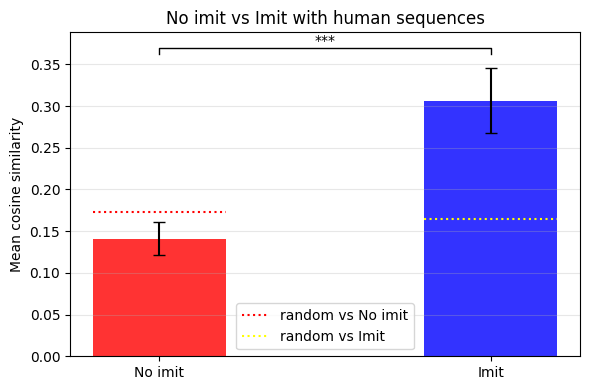

In [42]:
import matplotlib.pyplot as plt
from scipy import stats

# 1) 인간 행동 시퀀스 불러오기
human_vectors, human_num_actions = sample_human_action_sequences(
    seq_len=SEQ_LEN,
    num_seqs=NUM_SEQS,
    subject=HUMAN_SUBJECT,
    session=HUMAN_SESSION,
    block=HUMAN_BLOCK,
    game_id=HUMAN_GAME_ID,
    base_dir=HUMAN_BASE_DIR,
)
print(f"[human] vectors shape: {human_vectors.shape}, num_actions={human_num_actions}")

# 2) Thinker baseline 행동 시퀀스 불러오기
thinker_vectors, thinker_num_actions = sample_thinker_action_sequences(
    seq_len=SEQ_LEN,
    num_seqs=NUM_SEQS,
    thinker_dirs=THINKER_BASE_DIRS,
    num_actions_required=human_num_actions,
)
print(f"[thinker] vectors shape: {thinker_vectors.shape}, num_actions={thinker_num_actions}")

# 3) Imitation 에이전트 행동 시퀀스 불러오기
imit_vectors, imit_num_actions = sample_thinker_action_sequences(
    seq_len=SEQ_LEN,
    num_seqs=NUM_SEQS,
    thinker_dirs=IMIT_DIRS,
    num_actions_required=human_num_actions,
)
print(f"[imit] vectors shape: {imit_vectors.shape}, num_actions={imit_num_actions}")

# 4) L2 정규화
human_norm   = _normalize_rows(human_vectors)
thinker_norm = _normalize_rows(thinker_vectors)
imit_norm    = _normalize_rows(imit_vectors)

# 5) 코사인 유사도 샘플링 (인간 vs 각 에이전트)
max_pairs = min(len(human_norm), len(thinker_norm), len(imit_norm), NUM_PAIRS)
if max_pairs < 2:
    raise RuntimeError(f"Not enough sequences for similarity comparison (pairs={max_pairs}).")

idx_h = rng.integers(0, len(human_norm),   size=max_pairs)
idx_t = rng.integers(0, len(thinker_norm), size=max_pairs)
idx_i = rng.integers(0, len(imit_norm),    size=max_pairs)

cos_ht = np.einsum("ij,ij->i", human_norm[idx_h], thinker_norm[idx_t])  # human vs thinker
cos_hi = np.einsum("ij,ij->i", human_norm[idx_h], imit_norm[idx_i])     # human vs imit

# 6) 랜덤 시퀀스 생성 후 각 에이전트와 비교 (baseline)
rand_actions_t = rng.integers(0, thinker_num_actions, size=(max_pairs, SEQ_LEN))
rand_onehot_t  = np.eye(thinker_num_actions, dtype=np.float32)[rand_actions_t]
rand_vectors_t = rand_onehot_t.reshape(max_pairs, -1)
rand_norm_t    = _normalize_rows(rand_vectors_t)
cos_tr = np.einsum("ij,ij->i", thinker_norm[idx_t], rand_norm_t)        # thinker vs random

rand_actions_i = rng.integers(0, imit_num_actions, size=(max_pairs, SEQ_LEN))
rand_onehot_i  = np.eye(imit_num_actions, dtype=np.float32)[rand_actions_i]
rand_vectors_i = rand_onehot_i.reshape(max_pairs, -1)
rand_norm_i    = _normalize_rows(rand_vectors_i)
cos_ir = np.einsum("ij,ij->i", imit_norm[idx_i], rand_norm_i)           # imit vs random

# 7) 요약 통계 출력
def summary(name, x):
    print(f"{name}: mean = {x.mean():.4f}, std = {x.std(ddof=1):.4f}")

print("=== Cosine similarity (human vs Thinker / Imit) ===")
summary("human vs Thinker", cos_ht)
summary("human vs Imit   ", cos_hi)

print("=== Cosine similarity (random vs Thinker / Imit) ===")
summary("random vs Thinker", cos_tr)
summary("random vs Imit   ", cos_ir)

# 8) 바 플롯 + 유의성 (*) 표시 (random은 점선만)
def mean_ci_95(x):
    x = np.asarray(x, dtype=float)
    if x.size <= 1:
        return x.mean(), 0.0
    m = x.mean()
    e = stats.sem(x) * 1.96  # 95% CI
    return m, e

m_ht, ci_ht = mean_ci_95(cos_ht)
m_hi, ci_hi = mean_ci_95(cos_hi)
m_tr, ci_tr = mean_ci_95(cos_tr)
m_ir, ci_ir = mean_ci_95(cos_ir)

labels = ["No imit", "Imit"]
x = np.arange(len(labels))
bar_width = 0.4
colors = ["red", "blue"]

fig, ax = plt.subplots(figsize=(6, 4))

means = [m_ht, m_hi]
cis   = [ci_ht, ci_hi]
bars = ax.bar(x, means, yerr=cis, color=colors, alpha=0.8, capsize=4, width=bar_width)

# 유의성(*) 표시 함수
def add_sig(ax, x1, x2, y, p):
    if p < 0.001:
        mark = "***"
    elif p < 0.01:
        mark = "**"
    elif p < 0.05:
        mark = "*"
    else:
        mark = "ns"
    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color="black", lw=1)
    ax.text((x1 + x2) / 2, y + h, mark, ha="center", va="bottom")

# Human 기반 Thinker vs Imit 비교
t_stat_h, p_val_h = stats.ttest_ind(cos_ht, cos_hi, equal_var=False)
y_h = max(bars[0].get_height() + cis[0], bars[1].get_height() + cis[1]) * 1.05
add_sig(ax, x[0], x[1], y_h, p_val_h)

# Random baseline: 각 bar에 해당하는 점선
# Thinker random baseline (빨간 점선)
ax.hlines(
    y=m_tr,
    xmin=x[0] - bar_width/2,
    xmax=x[0] + bar_width/2,
    colors="red",
    linestyles=":",
    label="random vs No imit",
)

# Imit random baseline (파란 점선)
ax.hlines(
    y=m_ir,
    xmin=x[1] - bar_width/2,
    xmax=x[1] + bar_width/2,
    colors="yellow",
    linestyles=":",
    label="random vs Imit",
)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean cosine similarity")
ax.set_title("No imit vs Imit with human sequences")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()



# heat map visualization

In [19]:
import numpy as np
#data = np.load('/home/jmme425/thinker/behavioral_data_block/sub_1/game_2/day_1/block_3/sub1-game2-day1-block3-block-27192.npz')
data = np.load('/home/jmme425/thinker/behavioral_data_block/sub-001/ses-01/sub001-ses01-block3-game2.npz')
term_idx = np.flatnonzero(data["is_first"])
term_idx2 = np.flatnonzero(data["is_terminal"])
print(term_idx)
print("start count:", term_idx.size)
print(term_idx2)
print("end count:", term_idx2.size)

[    0  4501  8874 14105 21310 26471]
start count: 6
[ 4500  8873 14104 21309 26470 27191]
end count: 6
